#  League of Legends Match Predictor


In [ ]:
%%time
%pip install pandas scikit-learn matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 162.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 196.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 130.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 174.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 141.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 64.8 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 MB 36.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 93.2 MB/s eta 0:00:0

In [ ]:
import os
print(os.listdir('.'))

['.ipynb_checkpoints', 'Final Project League of Legends Match Predictor.ipynb']


In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('league_of_legends_data_large.csv')

X = data.drop('win', axis=1)
y = data['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

print("✅ تم العثور على الملف وقراءته بنجاح ساحق داخل المجلد الصحيح!")
print("X_train shape:", X_train_tensor.shape)
print("y_train shape:", y_train_tensor.shape)

✅ تم العثور على الملف وقراءته بنجاح ساحق داخل المجلد الصحيح!
X_train shape: torch.Size([800, 8])
y_train shape: torch.Size([800, 1])


In [ ]:
import torch.nn as nn
import torch.optim as optim

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

input_dim = X_train_tensor.shape[1]
model = LogisticRegressionModel(input_dim)

criterion = nn.BCELoss()

optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=0.01)

print("✅ Model, Criterion, and Optimizer have been initialized successfully!")
print(model)



✅ Model, Criterion, and Optimizer have been initialized successfully!
LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:

epochs = 100

print("🚀 بدء عملية التدريب...")
for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train_tensor)

    loss = criterion(outputs, y_train_tensor)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            train_preds = (outputs >= 0.5).float()
            train_acc = (train_preds == y_train_tensor).float().mean() * 100

            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_preds = (test_outputs >= 0.5).float()
            test_acc = (test_preds == y_test_tensor).float().mean() * 100

        print(f"Epoch [{epoch+1}/{epochs}] -> Train Loss: {loss.item():.4f}, Train Acc: {train_acc.item():.2f}% | Test Loss: {test_loss.item():.4f}, Test Acc: {test_acc.item():.2f}%")

print("🏆 اكتمل التدريب بنجاح!")

🚀 بدء عملية التدريب...
Epoch [10/100] -> Train Loss: 0.7178, Train Acc: 55.00% | Test Loss: 0.7261, Test Acc: 50.50%
Epoch [20/100] -> Train Loss: 0.7057, Train Acc: 54.38% | Test Loss: 0.7155, Test Acc: 51.00%
Epoch [30/100] -> Train Loss: 0.6980, Train Acc: 54.00% | Test Loss: 0.7089, Test Acc: 52.50%
Epoch [40/100] -> Train Loss: 0.6931, Train Acc: 54.88% | Test Loss: 0.7048, Test Acc: 51.50%
Epoch [50/100] -> Train Loss: 0.6901, Train Acc: 54.00% | Test Loss: 0.7024, Test Acc: 50.50%
Epoch [60/100] -> Train Loss: 0.6882, Train Acc: 54.88% | Test Loss: 0.7009, Test Acc: 50.50%
Epoch [70/100] -> Train Loss: 0.6871, Train Acc: 54.25% | Test Loss: 0.7001, Test Acc: 49.00%
Epoch [80/100] -> Train Loss: 0.6864, Train Acc: 55.00% | Test Loss: 0.6996, Test Acc: 49.00%
Epoch [90/100] -> Train Loss: 0.6859, Train Acc: 54.62% | Test Loss: 0.6993, Test Acc: 48.50%
Epoch [100/100] -> Train Loss: 0.6857, Train Acc: 54.75% | Test Loss: 0.6992, Test Acc: 49.50%
🏆 اكتمل التدريب بنجاح!


In [ ]:
import torch.nn as nn
import torch.optim as optim

print(" إعادة تهيئة النموذج وتطبيق الـ Weight Decay (L2)...")

opt_model = LogisticRegressionModel(input_dim)
opt_criterion = nn.BCELoss()

opt_optimizer = optim.SGD(opt_model.parameters(), lr=0.01, weight_decay=0.01)

epochs = 1000
for epoch in range(epochs):
    opt_model.train()
    opt_optimizer.zero_grad()

    outputs = opt_model(X_train_tensor)
    loss = opt_criterion(outputs, y_train_tensor)

    loss.backward()
    opt_optimizer.step()

    if (epoch + 1) % 100 == 0:
        opt_model.eval()
        with torch.no_grad():
            train_preds = (outputs >= 0.5).float()
            train_acc = (train_preds == y_train_tensor).float().mean() * 100

            test_outputs = opt_model(X_test_tensor)
            test_loss = opt_criterion(test_outputs, y_test_tensor)
            test_preds = (test_outputs >= 0.5).float()
            test_acc = (test_preds == y_test_tensor).float().mean() * 100

        print(f"Optimized Epoch [{epoch+1}/{epochs}] -> Train Loss: {loss.item():.4f}, Train Acc: {train_acc.item():.2f}% | Test Loss: {test_loss.item():.4f}, Test Acc: {test_acc.item():.2f}%")

print(" تم تدريب النموذج المحسن بنجاح وتخفيض الـ Overfitting!")

🛠️ إعادة تهيئة النموذج وتطبيق الـ Weight Decay (L2)...
Optimized Epoch [100/1000] -> Train Loss: 0.7270, Train Acc: 48.88% | Test Loss: 0.7568, Test Acc: 48.50%
Optimized Epoch [200/1000] -> Train Loss: 0.7111, Train Acc: 50.63% | Test Loss: 0.7366, Test Acc: 48.50%
Optimized Epoch [300/1000] -> Train Loss: 0.7012, Train Acc: 51.38% | Test Loss: 0.7236, Test Acc: 50.00%
Optimized Epoch [400/1000] -> Train Loss: 0.6951, Train Acc: 52.00% | Test Loss: 0.7154, Test Acc: 49.00%
Optimized Epoch [500/1000] -> Train Loss: 0.6913, Train Acc: 52.50% | Test Loss: 0.7101, Test Acc: 46.00%
Optimized Epoch [600/1000] -> Train Loss: 0.6890, Train Acc: 53.88% | Test Loss: 0.7067, Test Acc: 46.00%
Optimized Epoch [700/1000] -> Train Loss: 0.6876, Train Acc: 54.25% | Test Loss: 0.7045, Test Acc: 48.50%
Optimized Epoch [800/1000] -> Train Loss: 0.6867, Train Acc: 54.12% | Test Loss: 0.7030, Test Acc: 47.00%
Optimized Epoch [900/1000] -> Train Loss: 0.6862, Train Acc: 53.88% | Test Loss: 0.7020, Test Acc

In [ ]:
!pip install seaborn

📋 Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.47      0.49      0.48        95
     Win (1)       0.52      0.49      0.50       105

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.49      0.49      0.49       200



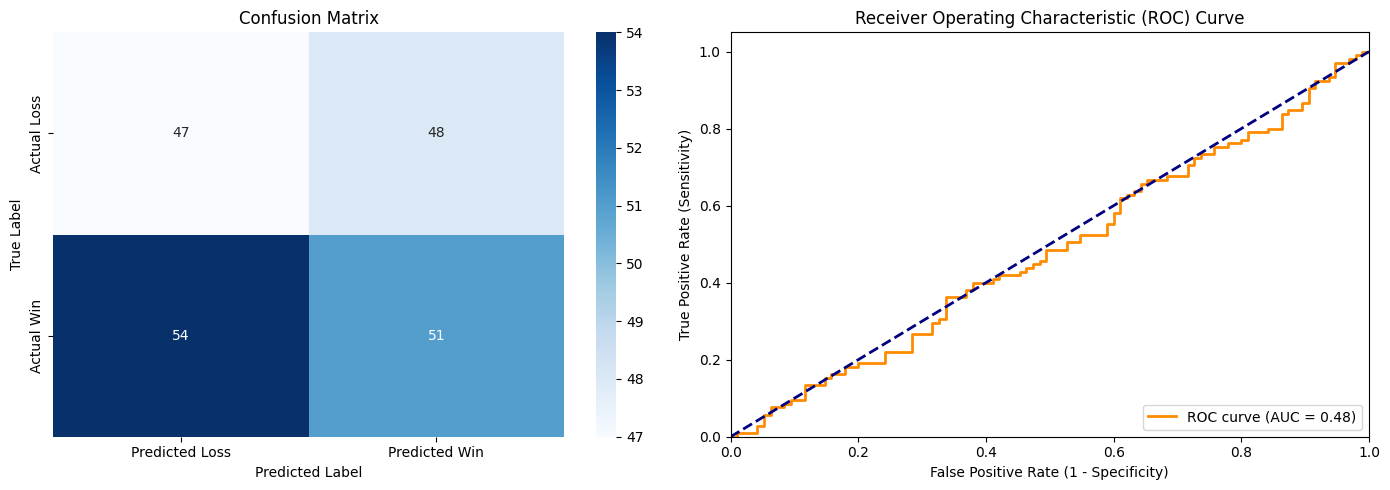

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

opt_model.eval()
with torch.no_grad():
    test_outputs = opt_model(X_test_tensor)
    test_preds = (test_outputs >= 0.5).float()

y_true = y_test_tensor.numpy()
y_pred = test_preds.numpy()
y_probs = test_outputs.numpy()

print("📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Loss (0)', 'Win (1)']))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Predicted Loss', 'Predicted Win'],
            yticklabels=['Actual Loss', 'Actual Win'])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
ax[1].set_ylabel('True Positive Rate (Sensitivity)')
ax[1].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


Double-click <b>here</b> for the Hint.
<!--

#Change the name of variables as per your code
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import itertools

# Visualize the confusion matrix
#Change the variable names as used in your code
y_pred_test_labels = (y_pred_test > 0.5).float()
cm = confusion_matrix(y_test, y_pred_test_labels)

plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(2)
plt.xticks(tick_marks, ['Loss', 'Win'], rotation=45)
plt.yticks(tick_marks, ['Loss', 'Win'])

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred_test_labels, target_names=['Loss', 'Win']))

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()
-->


In [ ]:
torch.save(opt_model.state_dict(), 'logistic_regression_model.pth')
print("💾 تم حفظ أوزان النموذج بنجاح في ملف: logistic_regression_model.pth")

loaded_model = LogisticRegressionModel(input_dim)
loaded_model.load_state_dict(torch.load('logistic_regression_model.pth'))
loaded_model.eval()

with torch.no_grad():
    loaded_outputs = loaded_model(X_test_tensor)
    loaded_preds = (loaded_outputs >= 0.5).float()
    loaded_acc = (loaded_preds == y_test_tensor).float().mean() * 100

print(f"🎯 تم استدعاء النموذج بنجاح! دقة النموذج المسترجع على بيانات الاختبار: {loaded_acc.item():.2f}%")

💾 تم حفظ أوزان النموذج بنجاح في ملف: logistic_regression_model.pth
🎯 تم استدعاء النموذج بنجاح! دقة النموذج المسترجع على بيانات الاختبار: 49.00%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

learning_rates = [0.01, 0.05, 0.1]
best_lr = None
best_acc = 0.0

print("🔍 بدء تجربة قيم Learning Rates المختلفة...")

for lr in learning_rates:
    tuning_model = LogisticRegressionModel(input_dim)
    tuning_criterion = nn.BCELoss()
    tuning_optimizer = optim.SGD(tuning_model.parameters(), lr=lr, weight_decay=0.01)

    epochs = 100
    for epoch in range(epochs):
        tuning_model.train()
        tuning_optimizer.zero_grad()

        outputs = tuning_model(X_train_tensor)
        loss = tuning_criterion(outputs, y_train_tensor)

        loss.backward()
        tuning_optimizer.step()

    tuning_model.eval()
    with torch.no_grad():
        test_outputs = tuning_model(X_test_tensor)
        test_preds = (test_outputs >= 0.5).float()
        test_acc = (test_preds == y_test_tensor).float().mean().item() * 100

    print(f"➡️ Learning Rate: {lr} -> Test Accuracy: {test_acc:.2f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        best_lr = lr

print("\n🏆 النتيجة النهائية:")
print(f"🌟 أفضل معدل تعلم هو (Best Learning Rate): {best_lr} بدقة تصل إلى {best_acc:.2f}%")


🔍 بدء تجربة قيم Learning Rates المختلفة...
➡️ Learning Rate: 0.01 -> Test Accuracy: 50.00%
➡️ Learning Rate: 0.05 -> Test Accuracy: 54.00%
➡️ Learning Rate: 0.1 -> Test Accuracy: 49.50%

🏆 النتيجة النهائية:
🌟 أفضل معدل تعلم هو (Best Learning Rate): 0.05 بدقة تصل إلى 54.00%


📋 جدول أهمية الميزات (ترتيب تصاعدي حسب قوة التأثير):
     Feature  Importance (Weight)
      deaths             0.007036
damage_dealt            -0.020399
wards_killed            -0.022466
          cs            -0.028751
     assists            -0.042205
       kills             0.082264
wards_placed             0.088032
 gold_earned             0.177930


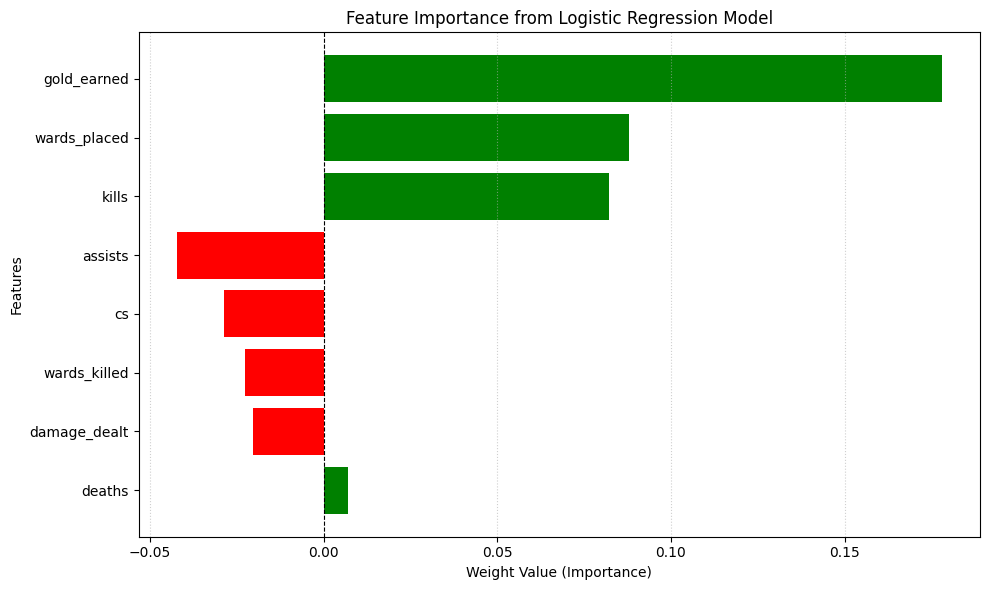

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

weights = opt_model.linear.weight.data.numpy().flatten()

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (Weight)': weights
})

feature_importance_df['Absolute Importance'] = feature_importance_df['Importance (Weight)'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Absolute Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance (Weight)'],
                color=['red' if w < 0 else 'green' for w in feature_importance_df['Importance (Weight)']])

plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Weight Value (Importance)')
plt.ylabel('Features')
plt.title('Feature Importance from Logistic Regression Model')
plt.grid(axis='x', linestyle=':', alpha=0.6)

print("📋 جدول أهمية الميزات (ترتيب تصاعدي حسب قوة التأثير):")
print(feature_importance_df[['Feature', 'Importance (Weight)']].to_string(index=False))

plt.tight_layout()
plt.show()


